# Calogero-Sutherland Model — Exact Wavefunction Test

**Hamiltonian** (convention $\hbar^2/m = 1$, so kinetic $= -\sum_i \partial^2/\partial x_i^2$):

$$H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1) \sum_{i<j} \frac{1}{(x_i - x_j)^2}$$

**Exact ground state:**

$$\psi_0(x) = C \prod_{i<j} |x_i - x_j|^L \cdot \exp\!\left(-\tfrac{1}{2}\sum_i x_i^2\right)$$

$$\log|\psi_0| = L \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

**Exact ground state energy** (in code convention, $\omega=1$):

$$E_0 = N\bigl(1 + L(N-1)\bigr) \qquad \Longrightarrow \qquad E_0/N = 1 + L(N-1)$$

**This notebook trains the exact model** — a single learnable parameter $\lambda$ in the Jastrow factor.
When $\lambda \to L$, the energy converges exactly to $E_0$.

## Imports

In [1]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

NOT IMPLEMENTED YET: PairLogExponentialMLPwithGaussianPenalty


## System

In [2]:
N_PARTICLES = 5      # number of particles
DIM         = 1
L           = 0.1   # CS coupling; exact λ = L in the Jastrow factor

N_CHAINS = 2_000
DoF      = N_PARTICLES * DIM
SHAPE    = (N_CHAINS, DoF)

# Exact energy in code convention (H = -Σ∂² + V, ω=1)
E_EXACT_TOTAL = N_PARTICLES * (1 + L * (N_PARTICLES - 1))
E_EXACT       = E_EXACT_TOTAL / N_PARTICLES   # per particle

print(f"N = {N_PARTICLES},  L = {L}")
print(f"E₀ (total)      = {E_EXACT_TOTAL:.4f}")
print(f"E₀ (per particle) = {E_EXACT:.4f}")

N = 5,  L = 0.1
E₀ (total)      = 7.0000
E₀ (per particle) = 1.4000


## Model

The `CalogeroSutherlandAnalyticModel` implements the exact log-wavefunction with one learnable parameter $\lambda$:

$$\log|\psi| = \lambda \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

Setting `lambda_init = L` starts at the exact solution. Any other starting value tests convergence.

In [3]:
LAMBDA_INIT = 0.5   # starting guess for λ; converges to L during training

model        = CalogeroSutherlandAnalyticModel(lambda_init=LAMBDA_INIT)
IS_LOG_MODEL = True

print(f"λ init = {LAMBDA_INIT}   →   target λ = {L}")

λ init = 0.5   →   target λ = 0.1


## Hamiltonian

`epsilon` softens the $1/(x_i-x_j)^2$ singularity; set it small but nonzero for numerical stability.

In [4]:
hamiltonian = CalogeroSutherlandHamiltonian(L=L, epsilon=1e-12)

## Optimizer

In [5]:
LEARNING_RATE = 1e-3
optimizer     = optax.adam(learning_rate=LEARNING_RATE)

## Sampler

In [6]:
CHAIN_LENGTH = 50

sampler_params = {
    "step_size":            0.5,
    "chain_length":         CHAIN_LENGTH + 1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor":      1,
    "PBC":                  40.0,
}

## Training

In [7]:
cfg = TrainingConfig(
    n_epochs=3_000,
    rng_seed=42,
    warm_walkers=True,
    is_update_step_size=True,
    is_log_model=IS_LOG_MODEL,
    min_step=1e-5,
    max_step=5.0,
)

history, cm_mean, cm_std = train(
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    hamiltonian=hamiltonian,
    training_config=cfg,
    sampler_params=sampler_params,
    coord_mode=LabCoords(),
)

100%|██████████| 3000/3000 [00:08<00:00, 355.99it/s, E=24.8767, sigma_E=44.2727]      


## Extract History

In [8]:
energies   = np.array([float(s.energy) for s in history]) / N_PARTICLES
stds       = np.array([float(s.std)    for s in history]) / N_PARTICLES
acc_rates  = np.array([float(jnp.mean(s.acceptance_rate)) for s in history])
step_sizes = np.array([float(s.step_size) for s in history])
lambdas    = np.array([float(s.params["params"]["lam"]) for s in history])
steps      = np.arange(len(history))

## Summary

In [9]:
TAIL = 200
final_E   = energies[-TAIL:].mean()
final_std = stds[-TAIL:].mean()
final_lam = lambdas[-1]

print(f"L (exact coupling)     : {L}")
print(f"λ final                : {final_lam:.6f}   (target: {L})")
print(f"λ error                : {abs(final_lam - L):.2e}")
print()
print(f"E₀/N (exact)           : {E_EXACT:.6f}")
print(f"E/N  (last {TAIL})       : {final_E:.6f} ± {final_std:.6f}")
print(f"|E - E₀|/N             : {abs(final_E - E_EXACT):.2e}")
print(f"Relative error         : {abs(final_E - E_EXACT) / E_EXACT * 100:.4f}%")
print(f"Final acceptance rate  : {acc_rates[-TAIL:].mean():.3f}")
print(f"Final step size        : {step_sizes[-1]:.4f}")

L (exact coupling)     : 0.1
λ final                : 0.745210   (target: 0.1)
λ error                : 6.45e-01

E₀/N (exact)           : 1.400000
E/N  (last 200)       : 4.784310 ± 6.239997
|E - E₀|/N             : 3.38e+00
Relative error         : 241.7364%
Final acceptance rate  : 0.500
Final step size        : 0.2650


## Plots

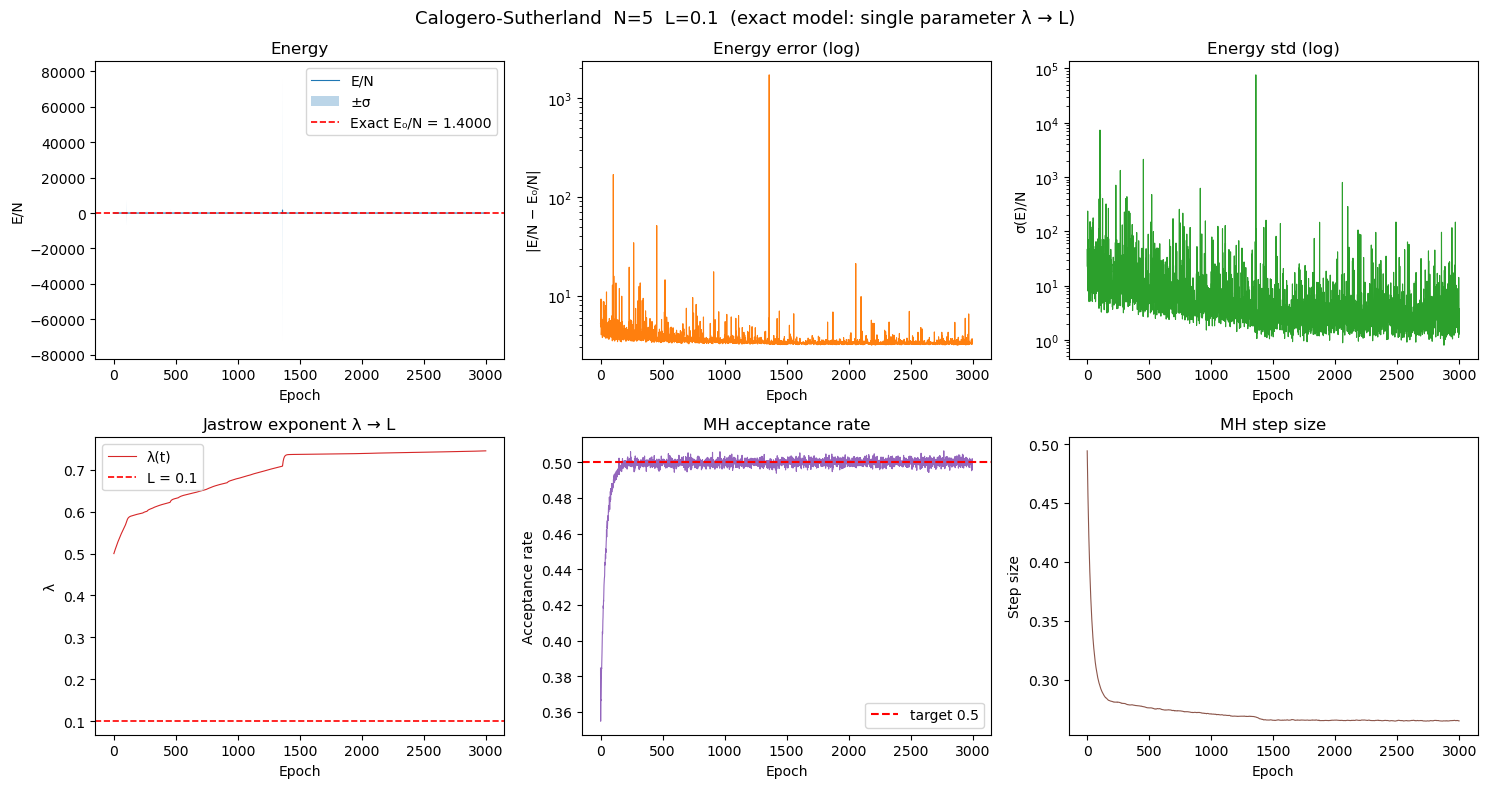

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f"Calogero-Sutherland  N={N_PARTICLES}  L={L}  "
    f"(exact model: single parameter λ → L)",
    fontsize=13,
)

ax = axes[0, 0]
ax.plot(steps, energies, lw=0.8, label='E/N')
ax.fill_between(steps, energies - stds, energies + stds, alpha=0.3, label='±σ')
ax.axhline(E_EXACT, color='red', ls='--', lw=1.2, label=f'Exact E₀/N = {E_EXACT:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('E/N'); ax.set_title('Energy'); ax.legend()

ax = axes[0, 1]
ax.semilogy(steps, np.abs(energies - E_EXACT), lw=0.8, color='C1')
ax.set_xlabel('Epoch'); ax.set_ylabel('|E/N − E₀/N|'); ax.set_title('Energy error (log)')

ax = axes[0, 2]
ax.semilogy(steps, stds, lw=0.8, color='C2')
ax.set_xlabel('Epoch'); ax.set_ylabel('σ(E)/N'); ax.set_title('Energy std (log)')

ax = axes[1, 0]
ax.plot(steps, lambdas, lw=0.8, color='C3', label='λ(t)')
ax.axhline(L, color='red', ls='--', lw=1.2, label=f'L = {L}')
ax.set_xlabel('Epoch'); ax.set_ylabel('λ'); ax.set_title('Jastrow exponent λ → L'); ax.legend()

ax = axes[1, 1]
ax.plot(steps, acc_rates, lw=0.8, color='C4')
ax.axhline(0.5, color='red', ls='--', label='target 0.5')
ax.set_xlabel('Epoch'); ax.set_ylabel('Acceptance rate'); ax.set_title('MH acceptance rate'); ax.legend()

ax = axes[1, 2]
ax.plot(steps, step_sizes, lw=0.8, color='C5')
ax.set_xlabel('Epoch'); ax.set_ylabel('Step size'); ax.set_title('MH step size')

plt.tight_layout()
plt.savefig('cs_model_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Energy Scan

For each fixed $\lambda$ we resample from $|\psi_\lambda|^2$ and compute
$E(\lambda)/N = \langle\psi_\lambda|H|\psi_\lambda\rangle / N$.
The variational principle guarantees $E(\lambda) \ge E_0$, with the minimum at $\lambda = L$.

## Energy Scan

For the analytic wavefunction $\psi_\lambda = \prod_{i<j}|x_i-x_j|^\lambda \exp(-\tfrac{1}{2}\sum x_i^2)$,
the local energy simplifies exactly (the $\sum x_i^2$ terms cancel between kinetic and potential):

$$E_\text{loc}(x;\lambda) = \bigl[2\lambda(1-\lambda) + 2L(L-1)\bigr]\,A(x) + N + \lambda N(N-1), \qquad A(x)=\sum_{i<j}\frac{1}{(x_i-x_j)^2}$$

Since $\psi_\lambda$ is the exact eigenstate of $H(\lambda)=-\sum\partial^2+\sum x_i^2+2\lambda(\lambda{-}1)\sum_{i<j}(x_i{-}x_j)^{-2}$
with eigenvalue $N(1+\lambda(N{-}1))$, the Hellmann–Feynman theorem gives:

$$\langle A\rangle_\lambda = \frac{N(N-1)}{2(2\lambda-1)} \qquad (\lambda > \tfrac{1}{2})$$

**Why Monte Carlo fails for $\lambda < \tfrac{1}{2}$:**
The mean of $A(x)$ under $|\psi_\lambda|^2$ is
$\int |\psi_\lambda|^2 A\,dx \sim \int r^{2\lambda}\cdot r^{-2}\,dr = \int r^{2\lambda-2}\,dr$,
which converges only for $\lambda > \tfrac{1}{2}$.
Below this threshold the **mean energy is infinite** — Monte Carlo is not suffering from
large variance, it is trying to estimate $\infty$.
The pole in $\langle A\rangle_\lambda$ at $\lambda=\tfrac{1}{2}$ and the Monte Carlo blowup are the same phenomenon.

Substituting $\langle A\rangle_\lambda$ gives the **exact** variational energy with zero noise:

$$\frac{E_\text{var}(\lambda)}{N} = \frac{(N-1)\bigl[2\lambda(1-\lambda)+2L(L-1)\bigr]}{2(2\lambda-1)} + 1 + \lambda(N-1), \qquad \lambda > \tfrac{1}{2}$$

/tmp/ipykernel_14061/3525200592.py:11: RuntimeWarning: divide by zero encountered in divide
  A_mean     = N * (N - 1) / (2 * (2 * lam_values - 1))


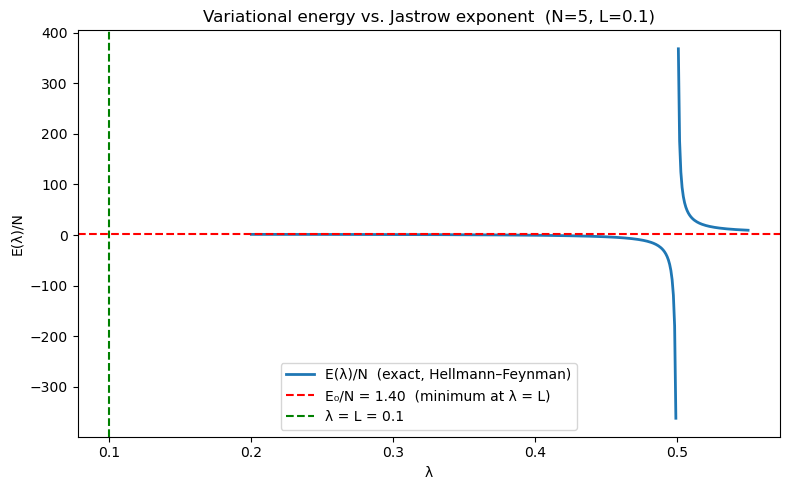

Minimum E/N = -361.80175439  at λ = 0.499123
Exact E₀/N = 1.40000000              at λ = 0.1


In [11]:
# Exact variational energy via Hellmann-Feynman — no Monte Carlo, no variance
#
# <Σᵢ<ⱼ 1/(xᵢ-xⱼ)²>_λ = N(N-1) / [2(2λ-1)]   (valid for λ > 1/2)
# E_var(λ)  = [2λ(1-λ) + 2L(L-1)] * <A>_λ + N + λN(N-1)

import warnings
N = N_PARTICLES

lam_values = np.linspace(0.55, 2.0 * L, 400)   # start just above the λ=½ pole

A_mean     = N * (N - 1) / (2 * (2 * lam_values - 1))
E_analytic = (
    (2 * lam_values * (1 - lam_values) + 2 * L * (L - 1)) * A_mean
    + N + lam_values * N * (N - 1)
) / N

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lam_values, E_analytic, lw=2.0, color='C0',
        label='E(λ)/N  (exact, Hellmann–Feynman)')
ax.axhline(E_EXACT, color='red',   ls='--', lw=1.5,
           label=f'E₀/N = {E_EXACT:.2f}  (minimum at λ = L)')
ax.axvline(L,       color='green', ls='--', lw=1.5,
           label=f'λ = L = {L}')
ax.set_xlabel('λ')
ax.set_ylabel('E(λ)/N')
ax.set_title(f'Variational energy vs. Jastrow exponent  (N={N}, L={L})')
ax.legend()
plt.tight_layout()
plt.savefig('cs_energy_scan.png', dpi=150, bbox_inches='tight')
plt.show()

idx_min = E_analytic.argmin()
print(f'Minimum E/N = {E_analytic[idx_min]:.8f}  at λ = {lam_values[idx_min]:.6f}')
print(f'Exact E₀/N = {E_EXACT:.8f}              at λ = {L}')

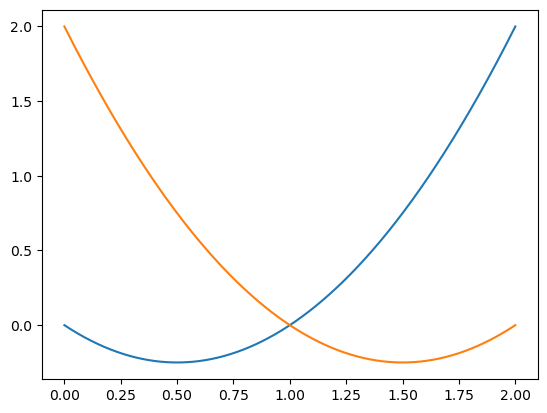

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lambdas = np.linspace(0,2, 1001)

y = lambdas * (lambdas-1)  # Example function of λ; replace with actual data
y_rev = (lambdas -1) * ((lambdas-1) - 1)

plt.plot(lambdas, y)
# plt.plot(lambdas, y_rev)
# plt.vlines(0.5, ymin=0, ymax=0.25, color='red', ls='--', label='λ=0.5 (pole)')